In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
)
train_data=fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)

    



In [4]:
test_data=fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)
    

In [5]:
X_train_text= train_data.data
Y_train=train_data.target
X_test_text=test_data.data
Y_test=test_data.target
class_names=train_data.target_names

In [6]:
print("Training documents:",len(X_train_text))
print("Testing documents:",len(X_test_text))
print("Number of classes:",len(class_names))


Training documents: 11314
Testing documents: 7532
Number of classes: 20


In [8]:
vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)
    

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [27]:
mnb=MultinomialNB()
mnb.fit(
    X_train,
    Y_train
)
y_pred_mnb=mnb.predict(X_test)
results=pd.DataFrame({
    "Model":[
        "Multinomial NB",
        "Bernoulli NB"
    ],
        "Accuracy":[ 
            accuracy_score(Y_test, y_pred_mnb),
            accuracy_score(Y_test, y_pred_bnb)
        ],
        "Precision":[
            precision_score(
                Y_test,
                y_pred_mnb,
                average="macro"
            ),
            precision_score(
                Y_test,
                y_pred_bnb,
                average="macro"
            )
        ],
        "Recall":[
            recall_score(
                Y_test,
                y_pred_mnb,
                average="macro"
            ),
            recall_score(
                Y_test,
                y_pred_bnb,
                average="macro"
            )
        ],
        "F1-Score":[
            f1_score(
                Y_test,
                y_pred_mnb,
                average="macro"
            ),
            f1_score(
                Y_test,
                y_pred_bnb,
                average="macro"
            )
        ]
})
print(results)


            Model  Accuracy  Precision    Recall  F1-Score
0  Multinomial NB  0.651089   0.634470  0.636933  0.617859
1    Bernoulli NB  0.485130   0.616678  0.469434  0.467865


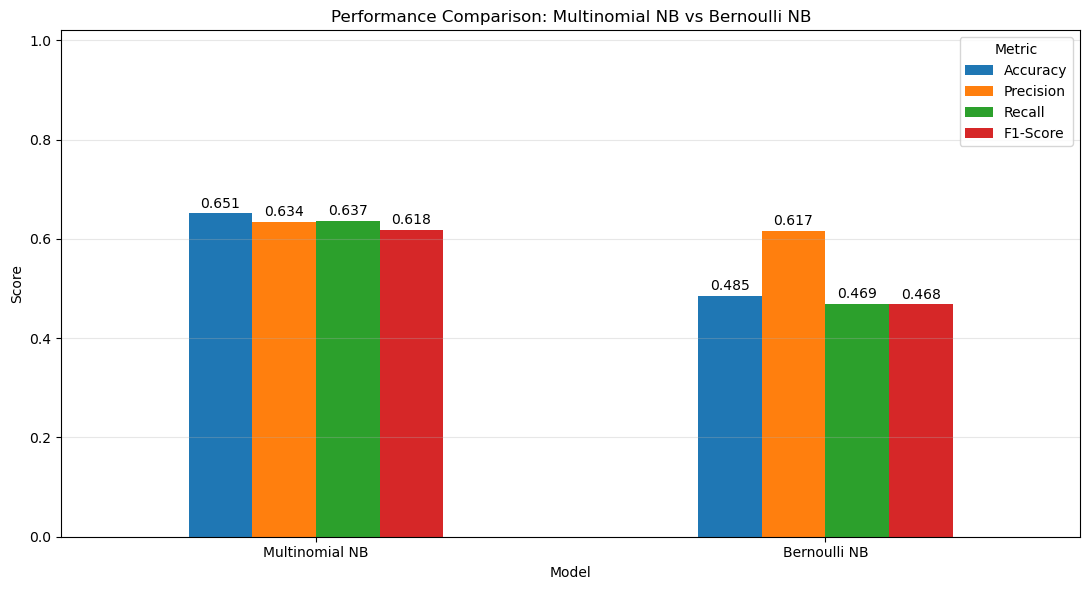

In [28]:
results_metrics=results[
    ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
]
ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6)
)
plt.title(
    "Performance Comparison: Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )
plt.tight_layout()
plt.show()